# **Author: Mukhamedali Daniyaruly**
# **Date: 24/05/2026**

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import math
from typing import Tuple

In [50]:
class SinusoidalTimeEmbedding(nn.Module):
  """Embeds a continuous time value t in [0, 1] into a high-dimensional vector."""
  def __init__(self, dim: int):
    super().__init__()

    self.dim = dim

  def forward(self, t: torch.Tensor) -> torch.Tensor:

    half_dim = self.dim // 2
    emb = math.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
    emb = t[:, None] * emb[None, :]
    emb = torch.cat((emb.sin(), emb.cos()), dim=-1)

    return emb

In [51]:
class AdaLN(nn.Module):
  """Adaptive Layer Normalization to inject time embedding."""
  def __init__(self, d_model: int):
    super().__init__()

    self.norm = nn.LayerNorm(d_model)

  def forward(self, x: torch.Tensor, scale: torch.Tensor, shift: torch.Tensor) -> torch.Tensor:
    return self.norm(x) * (1 + scale) + shift

In [52]:
class DiTBlock(nn.Module):
  """A single Diffusion Transformer Block with AdaLN conditioning."""
  def __init__(self, d_model: int, n_heads: int):
    super().__init__()

    self.d_model = d_model
    self.n_heads = n_heads

    # Adaptive Layer Normalization
    self.ada_ln1 = AdaLN(d_model)
    self.ada_ln2 = AdaLN(d_model)

    # Multi Linear Perceptron
    self.mlp = nn.Sequential(
        nn.Linear(d_model, d_model * 4),
        nn.SiLU(),
        nn.Linear(d_model * 4, d_model)
    )

    # Multi Head Attention
    self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, batch_first=True)

    # Projection Layer to project time into a high-dimensional vector.
    self.time_proj = nn.Linear(d_model, d_model * 4)

  def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    t_params = self.time_proj(t).unsqueeze(1)
    scale1, shift1, scale2, shift2 = t_params.chunk(4, dim=-1)

    # Attention path
    x_norm1 = self.ada_ln1(x, scale1, shift1)
    attn_out, _ = self.attn(x_norm1, x_norm1, x_norm1)
    x = x + attn_out

    # MLP path
    x_norm2 = self.ada_ln2(x, scale2, shift2)
    mlp_out = self.mlp(x_norm2)
    x = x + mlp_out

    return x

In [53]:
class FlowDiT(nn.Module):
  def __init__(self, in_channels: int = 1, image_size: int = 28, patch_size: int = 7, d_model: int = 128, n_heads: int = 4, depth: int = 3):
    super().__init__()

    self.patch_size = patch_size
    self.seq_len = (image_size // patch_size) ** 2

    self.patch_embed = nn.Conv2d(in_channels, d_model, kernel_size=patch_size, stride=patch_size)

    self.pos_embed = nn.Parameter(torch.randn(1, self.seq_len, d_model))
    self.time_mlp = nn.Sequential(
        SinusoidalTimeEmbedding(d_model),
        nn.Linear(d_model, d_model * 4),
        nn.SiLU(),
        nn.Linear(d_model * 4, d_model)
    )

    self.blocks = nn.ModuleList([DiTBlock(d_model, n_heads) for _ in range(depth)])

    self.head = nn.Linear(d_model, in_channels * patch_size * patch_size)

  def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    B, C, H, W = x.shape

    x = self.patch_embed(x).flatten(2).transpose(1, 2)

    x = x + self.pos_embed

    t_embed = self.time_mlp(t)

    for block in self.blocks:
      x = block(x, t_embed)

    x = self.head(x)

    P = self.patch_size
    H_out, W_out = H // P, W // P
    x = x.view(B, H_out, W_out, self.patch_embed.in_channels, P, P)
    x = x.permute(0, 3, 1, 4, 2, 5).contiguous().view(B, C, H, W)

    return x

In [54]:
def compute_flow_match_loss(model: nn.Module, x1: torch.Tensor) -> torch.Tensor:
  B = x1.shape[0]

  x0 = torch.randn_like(x1)

  t = torch.rand((B,), device=x1.device)
  t_expand = t.view(B, 1, 1, 1)

  xt = t_expand * x1 + (1 - t_expand) * x0

  target_velocity = x1 - x0

  pred_velocity = model(xt, t)

  loss = F.mse_loss(pred_velocity, target_velocity)

  return loss

In [77]:
def train():

  device = "cuda" if torch.cuda.is_available() else "cpu"

  transform = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize((0.5,), (0.5,))
  ])

  print(f"LOADING DATASET AND PREPARING...")
  dataset = datasets.MNIST(root="./", train=True, transform=transform, download=True)
  dataloader = DataLoader(dataset, shuffle=True, batch_size=256, drop_last=True)

  print(f"LOADING MODEL AND PREPARE OPTIMIZER...")
  model = FlowDiT(in_channels=1, image_size=28, patch_size=4, d_model=256, n_heads=4, depth=6).to(device)
  optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

  print(f"MODEL PARAMETERS: {sum(p.numel() for p in model.parameters()) / 1000000}M ...")

  epochs = 25
  for epoch in range(epochs):
    model.train()

    total_loss = 0.0

    for batch_idx, (images, _) in enumerate(dataloader):

      images = images.to(device)

      optimizer.zero_grad()
      loss = compute_flow_match_loss(model, images)
      loss.backward()
      optimizer.step()

      total_loss += loss.item()

      if batch_idx % 100 == 0:
        print(f"Epoch: {epoch}| Batch idx: {batch_idx}| loss: {loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    print(f"===Epoch: {epoch}| Average loss: {avg_loss:.4f} ===")

  return model

In [78]:
model = train()

LOADING DATASET AND PREPARING...
LOADING MODEL AND PREPARE OPTIMIZER...
MODEL PARAMETERS: 6.864144M ...
Epoch: 0| Batch idx: 0| loss: 2.5445
Epoch: 0| Batch idx: 100| loss: 0.6606
Epoch: 0| Batch idx: 200| loss: 0.4607
===Epoch: 0| Average loss: 0.6606 ===
Epoch: 1| Batch idx: 0| loss: 0.4136
Epoch: 1| Batch idx: 100| loss: 0.3893
Epoch: 1| Batch idx: 200| loss: 0.3656
===Epoch: 1| Average loss: 0.3947 ===
Epoch: 2| Batch idx: 0| loss: 0.3834
Epoch: 2| Batch idx: 100| loss: 0.3678
Epoch: 2| Batch idx: 200| loss: 0.3524
===Epoch: 2| Average loss: 0.3593 ===
Epoch: 3| Batch idx: 0| loss: 0.3621
Epoch: 3| Batch idx: 100| loss: 0.3299
Epoch: 3| Batch idx: 200| loss: 0.3286
===Epoch: 3| Average loss: 0.3380 ===
Epoch: 4| Batch idx: 0| loss: 0.3311
Epoch: 4| Batch idx: 100| loss: 0.3226
Epoch: 4| Batch idx: 200| loss: 0.3136
===Epoch: 4| Average loss: 0.3192 ===
Epoch: 5| Batch idx: 0| loss: 0.3104
Epoch: 5| Batch idx: 100| loss: 0.3056
Epoch: 5| Batch idx: 200| loss: 0.2850
===Epoch: 5| Ave

In [85]:
def inference(model: nn.Module, timesteps: int = 50):
    device = next(model.parameters()).device # Get device from model

    model.eval() # Set model to evaluation mode

    # Initial sample from standard normal distribution (noise)
    x_current = torch.randn((1, 1, 28, 28), device=device)

    # Perform Euler integration
    # Time steps for integration from t=0 to t=1
    dt = torch.tensor(1.0 / timesteps, device=device)
    t_values = torch.linspace(0, 1 - dt, timesteps, device=device)
    with torch.no_grad(): # Disable gradient calculations
        for i in range(len(t_values) - 1):
            t_start = t_values[i]
            t_end = t_values[i+1]

            # Model predicts the velocity v(x_t, t)
            # Unsqueeze t_start to match batch dimension (1,) for the model's time_mlp
            v_pred = model(x_current, t_start.unsqueeze(0))

            # Euler step: x_{t+dt} = x_t + v(x_t, t) * dt
            x_current = x_current + v_pred * dt

    # Post-process the generated image
    generated_image = x_current.cpu().squeeze().numpy() # Remove batch and channel dims, convert to numpy

    # Denormalize the image from [-1, 1] to [0, 1] (assuming original normalization was (0.5, 0.5))
    generated_image = (generated_image * 0.5) + 0.5

    # Clip to ensure pixel values are within [0, 1] bounds
    generated_image = np.clip(generated_image, 0, 1)

    # Plot the generated image
    plt.imshow(generated_image, cmap='gray')
    plt.title(f"Generated MNIST Image after {timesteps} steps")
    plt.axis('off')
    plt.show()

    return generated_image

In [90]:
torch.save(model.state_dict(), "dit-6m-mnist.pth")

from google.colab import files

files.download("dit-6m-mnist.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

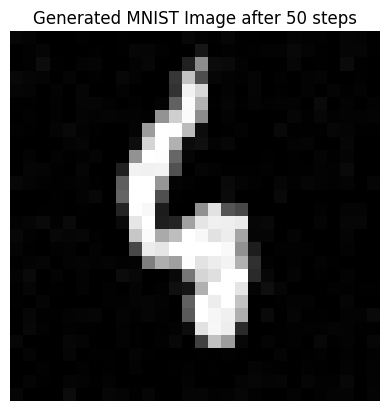

In [86]:
image = inference(model=model)

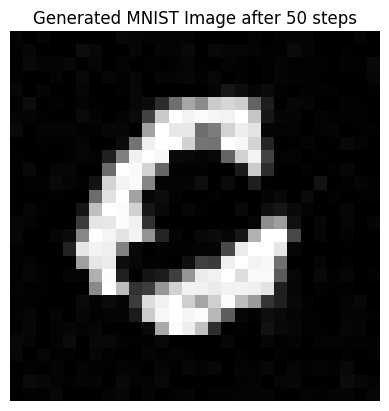

In [87]:
image = inference(model=model)

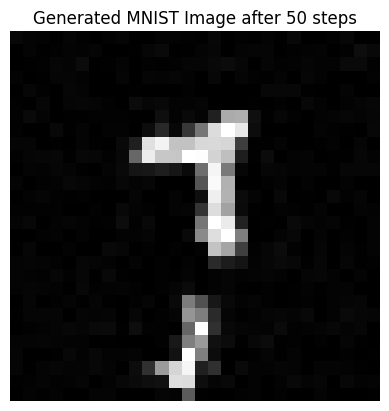

In [88]:
image = inference(model=model)